# Problem 1:
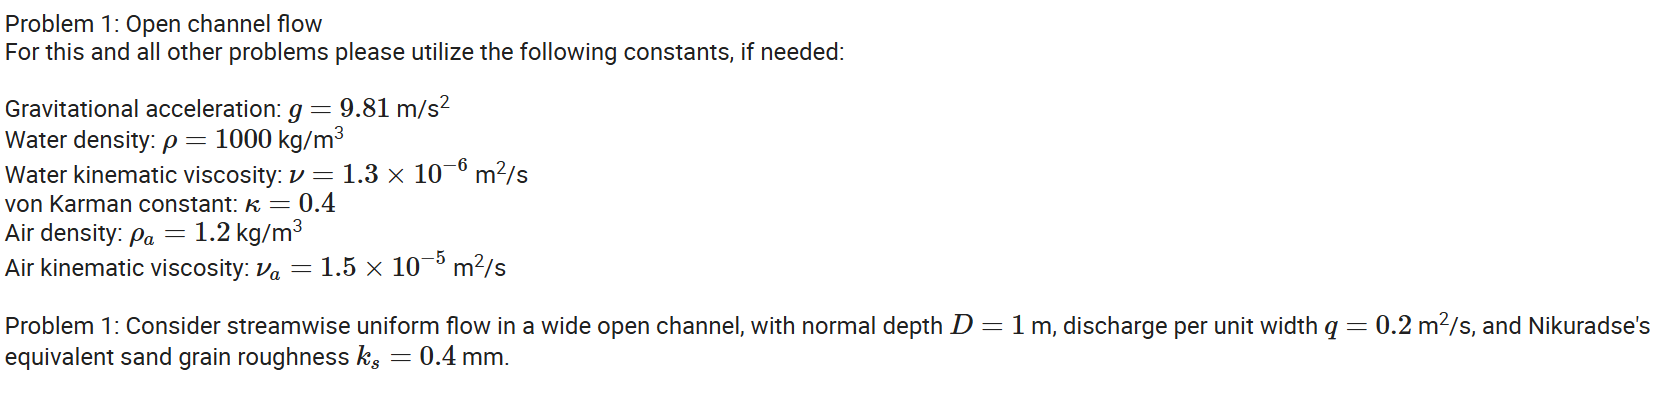

In [157]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
from scipy.special import erfc, erfcinv
from scipy.integrate import solve_ivp

In [158]:
# Given data
g = 9.81                    # gravitational acceleration (m/s^2)
viscosity = 1.3*10**-6      # kinematic viscosity of water (m^2/s)    
rho_water = 1000            # density of water (kg/m^3)
kappa = 0.4                 # von Karman constant
rho_air = 1.2               # air density (kg/m^3)
viscosity_air = 1.5*10**-5  # kinematic viscosity of air (m^2/s) 

D_norm = 1
q = 0.2
k_s = 0.4 * 10**-3


#### Question 1.1
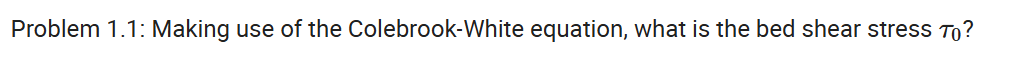

In [159]:
# ------------------------------------------------------------------
# System of equations to solve for D, calculate D_norm and flow type
# ------------------------------------------------------------------
def equations_solve_shear(unknowns):
    f, I = unknowns

    # Cross-sectional area and velocity
    D_norm = 1
    q = 0.2
    u = q/D_norm
    R = D_norm                           # Hydraulic radius [m] (R=D for wide channels)
    Re = R * u / viscosity               # Reynolds number [-]
    

    # Colebrook equation
    colebrook = np.sqrt(2 / f) - (6.4 - 2.45 * np.log(k_s / R + 4.7 / (Re * np.sqrt(f))))

    # Flow Resistance equation
    flow_resist = u - np.sqrt((2 * g * D_norm * I) / f)

    return [colebrook, flow_resist]


# -------------------------------
# Solve the system for slope I
# -------------------------------
initial_guess = [0.001, 0.000001]  # [f, I]
solution = fsolve(equations_solve_shear, initial_guess)
f_sol, I_sol = solution

# --------------------------
# Output results
# --------------------------
u_sol = q/D_norm
u_f = np.sqrt(g * (q / u_sol) * I_sol)  # np.sqrt(gDI)

shear = rho_water * g * D_norm * I_sol
print(f"Bed shear: {shear}")

Bed shear: 0.07207464766693156


#### Question 1.2
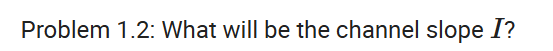

In [160]:
print(f"Slope {I_sol:.1e}")

Slope 7.3e-06


#### Question 1.3
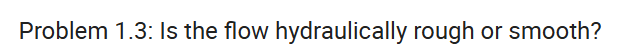

In [164]:
# -------------------------------
# Determine flow characteristics
# -------------------------------
def flow_regime(D, u_f, k_s_plus):
    # choose z0
    if k_s_plus > 70:
        z0 = k_s / 30.0            # hydraulically rough (Nikuradse)
        regime = "hydraulically rough"
    elif k_s_plus < 5:
        z0 = 0.11 * viscosity / u_f   # hydraulically smooth
        regime = "hydraulically smooth"
    else:
        # transitional: pick weighted average (simple pragmatic choice)
        z0_rough = k_s / 30.0
        z0_smooth = 0.11 * viscosity / u_f
        alpha = (k_s_plus - 5) / (70 - 5)
        z0 = (1 - alpha) * z0_smooth + alpha * z0_rough
        regime = "transitional"
    return regime, z0

# -------------------------------
# Get the results
# -------------------------------
k_s_plus = (k_s * u_sol) / viscosity
regime, z0 = flow_regime(D_norm, u_f, k_s_plus)

print(f"Flow regime: {regime}")

Flow regime: transitional


#### Question 1.4
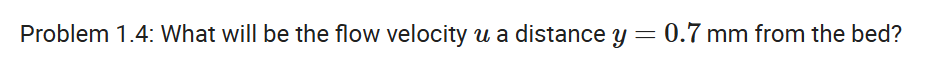

In [162]:
# Compute friction velocity and velocity at y=0.2 m using log-law
y = 0.7                   # height above bed [m] (given)

U_at_y = (u_f / kappa) * np.log(y / z0)

print("Mean (time averaged) flow velocity at height y:")
print(f"U(y={y} m) = {U_at_y:.2f} m/s")

Mean (time averaged) flow velocity at height y:
U(y=0.7 m) = 0.23 m/s


#### Question 1.5
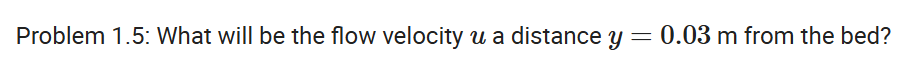

In [163]:
# Compute friction velocity and velocity at y=0.2 m using log-law
y = 0.03                   # height above bed [m] (given)

U_at_y = (u_f / kappa) * np.log(y / z0)

print("Mean (time averaged) flow velocity at height y:")
print(f"U(y={y} m) = {U_at_y:.2f} m/s")

Mean (time averaged) flow velocity at height y:
U(y=0.03 m) = 0.16 m/s
